## Leitura do csv

In [1]:
# carregar csv
import pandas as pd
import os
cenario = "NDT_AGO_OUT"
method = "vwcd_0.95"
file_path = os.path.join('metrics', cenario, method + '.csv')
df = pd.read_csv(file_path)

## Matriz de Correlação dos Changepoints

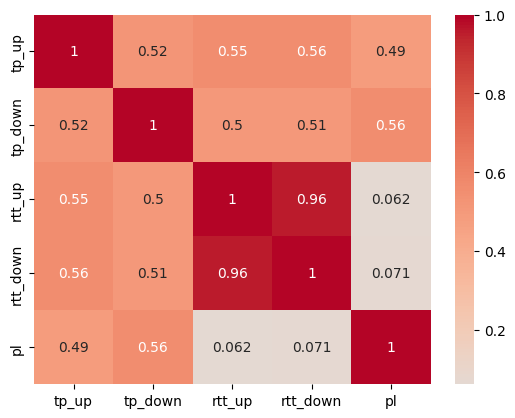

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
changepoints = ['tp_up', 'tp_down', 'rtt_up', 'rtt_down', 'pl']
correlation_matrix = df[changepoints].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.show()

* **`rtt_down` e `rtt_up`:** Correlação fortíssima (~0.95). Têm comportamento quase idêntico (dados redundantes).
* **`packet_loss` e Throughput (`tp_down`/`tp_up`):** Correlação moderada (~0.57). Perda de pacotes e banda variam juntas de forma mediana.
* **`tp_down` e `tp_up`:** Correlação moderada (~0.50). Seguem a mesma tendência, mas com certa independência.
* **`rtt` e `tp_down`:** Correlação moderada (~0.55). Relação mediana entre latência e banda de download.
* **`packet_loss` e `rtt`:** Correlação muito fraca (~0.10 a ~0.13). Variáveis quase totalmente independentes.

## Contagem de Changepoint por cliente/servidor

In [3]:
# Contar o número de clientes únicos e de servidores únicos
num_clientes_unicos = df['client'].nunique()
num_servidores_unicos = df['server'].nunique()
print(f"Número de clientes únicos: {num_clientes_unicos}")
print(f"Número de servidores únicos: {num_servidores_unicos}")

Número de clientes únicos: 16
Número de servidores únicos: 6


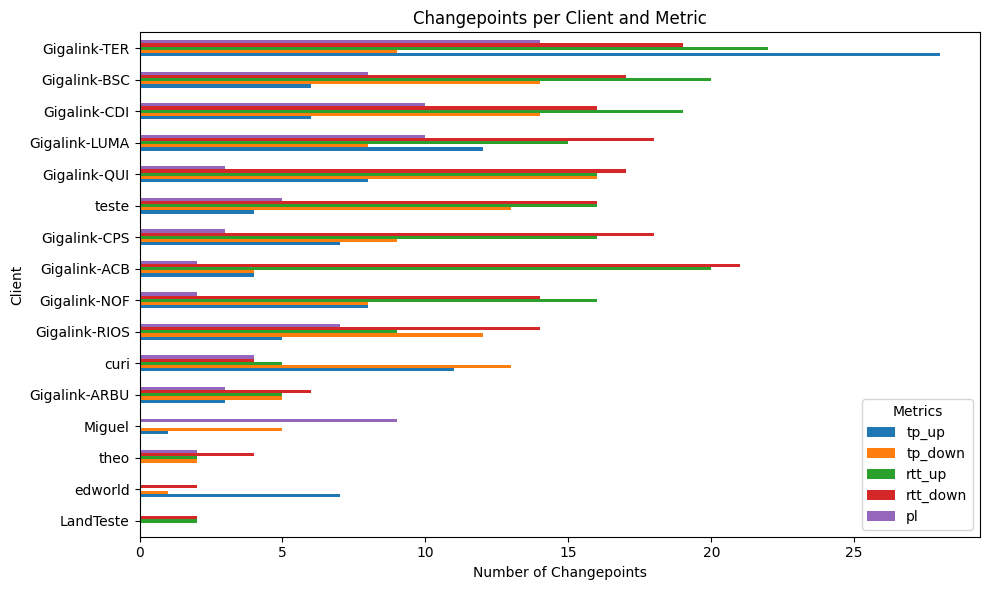

In [32]:
import matplotlib.pyplot as plt

df_grouped = df[['client']+changepoints].groupby('client').sum()
df_grouped = df_grouped.loc[df_grouped.sum(axis=1).sort_values(ascending=True).index]

ax = df_grouped.plot(kind='barh', figsize=(10, 6))
ax.set_title('Changepoints per Client and Metric')
ax.set_xlabel('Number of Changepoints')
ax.set_ylabel('Client')
ax.legend(title='Metrics')
plt.tight_layout()
plt.show()

* **Heterogeneidade na estabilidade:** Há uma divisão clara entre clientes muito instáveis (como `Gigalink-TER`, `Gigalink-BSC`, `Gigalink-CDI` e `Gigalink-QUI`), que acumulam um alto número de changepoints em várias métricas, e clientes bastante estáveis (como `theo`, `curi`, `edworld` e `Gigalink-ARBU`), com pouquíssimas alterações de comportamento.
* **Alta volatilidade da latência:** As métricas `rtt_up` e `rtt_down` (barras vermelha e laranja) são as responsáveis pelo maior número de changepoints na maioria dos clientes. Isso indica que a latência sofre degradações ou alterações significativas com muito mais frequência do que o throughput.
* **Reflexo visual da correlação:** É possível notar que as barras de `rtt_up` e `rtt_down` acompanham o mesmo ritmo de crescimento na grande maioria dos clientes (ex: `Gigalink-ACB`, `Gigalink-BSC`, `teste`). Isso confirma de forma prática a correlação fortíssima (~0.95) observada na sua matriz anterior.
* **Anomalia no `Gigalink-TER`:** Este cliente apresenta um pico extremo e fora do padrão na métrica `tp_up` (barra verde, passando de 20 changepoints). Nos demais clientes, o throughput de upload costuma ser uma das métricas mais estáveis.
* **Degradação geral em links específicos:** A métrica `packet_loss` geralmente apresenta poucos changepoints. No entanto, ela atinge valores altos justamente nos clientes que já sofrem com muita variação de RTT e throughput (como `Gigalink-TER` e `Gigalink-CDI`), indicando cenários de possível degradação severa e generalizada do QoS.

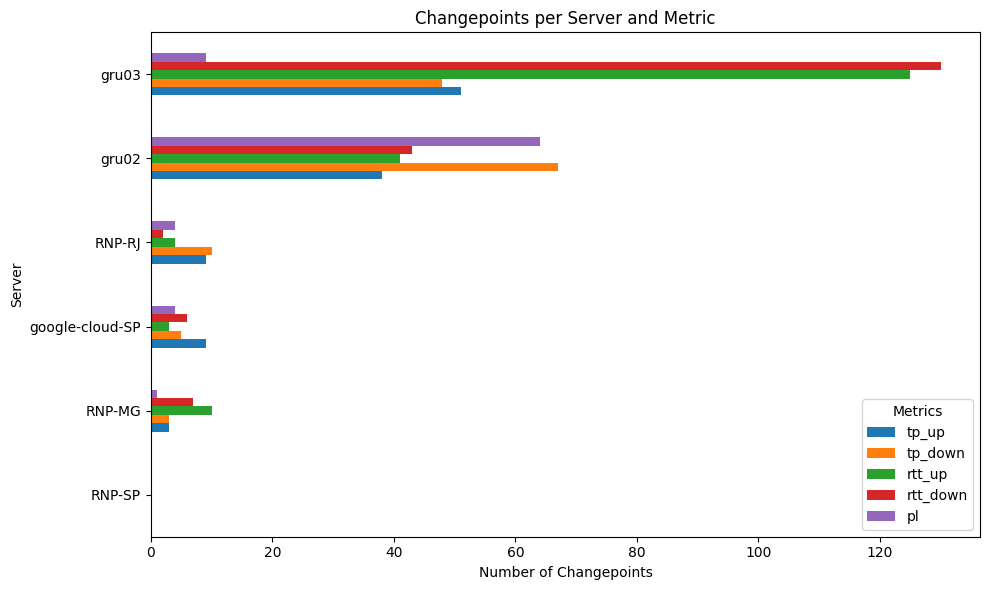

In [33]:
import matplotlib.pyplot as plt

df_grouped = df[['server']+changepoints].groupby('server').sum()
df_grouped = df_grouped.loc[df_grouped.sum(axis=1).sort_values(ascending=True).index]

ax = df_grouped.plot(kind='barh', figsize=(10, 6))
ax.set_title('Changepoints per Server and Metric')
ax.set_xlabel('Number of Changepoints')
ax.set_ylabel('Server')
ax.legend(title='Metrics')
plt.tight_layout()
plt.show()

* **Extrema concentração de instabilidade:** Os servidores `gru03` e `gru02` concentram a esmagadora maioria das mudanças de comportamento na rede. Em contraste, os servidores da infraestrutura RNP (`RNP-SP`, `RNP-RJ`, `RNP-MG`) e o `google-cloud-SP` são altamente estáveis.
* **`gru03` (Problemas de Latência):** É o servidor com o maior número absoluto de changepoints. Essa instabilidade é puxada quase inteiramente por variações severas de latência (as barras de `rtt_down` e `rtt_up` beiram ou ultrapassam 100). Curiosamente, a perda de pacotes (`packet_loss`) neste servidor é mínima.
* **`gru02` (Problemas de Perda e Throughput):** Apresenta um perfil de degradação bem diferente do `gru03`. O `gru02` tem o maior índice de `packet_loss` de todo o gráfico (passando de 50) e lidera a instabilidade no throughput de download (`tp_down`). É um cenário clássico de gargalo ou congestionamento que resulta em descarte de pacotes.
* **Estabilidade Exemplar:** O servidor `RNP-SP` não registrou nenhum changepoint no período analisado. Os demais servidores da base inferior registram números insignificantes (menos de 10), indicando que rotas para esses destinos mantêm um QoS muito consistente.
* **Reflexo da Correlação:** Novamente, as métricas de latência (`rtt_down` e `rtt_up`) caminham juntas (visível no `gru03`, `gru02` e até no pequeno registro do `RNP-MG`), ratificando a correlação de ~0.95 que você encontrou na matriz de Pearson.

# Relação entre métricas e número de changepoints

In [37]:
# normalizar a coluna tp_up_mean usando as colunas tp_up_min e tp_up_max
df['tp_up_m_norm'] = (df['tp_up_mean'] - df['tp_up_min']) / (df['tp_up_max'] - df['tp_up_min'])
# normalizar a coluna tp_down_mean usando as colunas tp_down_min e tp_down_max
df['tp_down_m_norm'] = (df['tp_down_mean'] - df['tp_down_min']) / (df['tp_down_max'] - df['tp_down_min'])

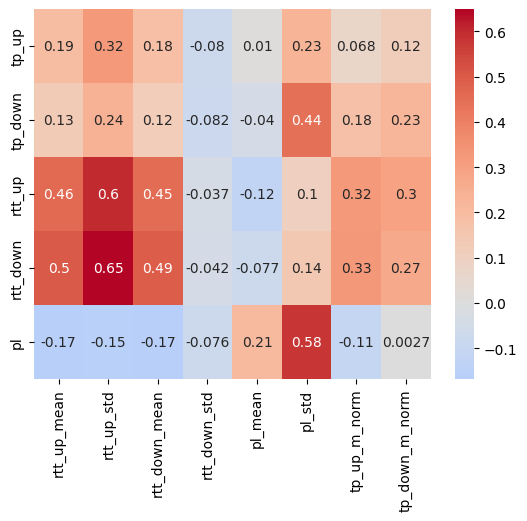

In [39]:
metrics = ["rtt_up_mean", "rtt_up_std", "rtt_down_mean", "rtt_down_std", "pl_mean", "pl_std", "tp_up_m_norm", "tp_down_m_norm"]
correlation_matrix = df[changepoints + metrics].corr().loc[changepoints, metrics]
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.show()